In [1]:
# ============================================================
# Cell 1: Imports & Environment Sanity Check
# (RF-DETR detection + ByteTrack tracking)
# ============================================================

# ---- Standard library ----
import os
import sys
import time
import json
import random
from pathlib import Path
from typing import List, Dict, Tuple, Optional

# ---- Numerical / scientific ----
import numpy as np

# ---- Computer vision / video I/O ----
import cv2

# ---- Visualization ----
import matplotlib.pyplot as plt

# ---- Deep learning ----
import torch

# ---- Detector ----
from rfdetr import RFDETRNano

# ---- Tracking (ByteTrack) ----
# supervision provides a ByteTrack wrapper that's convenient for notebooks
try:
    import supervision as sv
    SUPERVISION_OK = True
except Exception as e:
    SUPERVISION_OK = False
    print("Could not import supervision (needed for ByteTrack).")
    print(" Install with: pip install supervision")
    print(" Import error:", repr(e))

# ---- Utilities ----
from tqdm.auto import tqdm
import psutil

# ============================================================
# Environment sanity prints
# ============================================================

print("=== Environment Check ===")
print(f"Python version      : {sys.version.split()[0]}")
print(f"PyTorch version     : {torch.__version__}")
print(f"CUDA available      : {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"CUDA version        : {torch.version.cuda}")
    print(f"GPU                 : {torch.cuda.get_device_name(0)}")

print(f"CPU cores           : {psutil.cpu_count(logical=True)}")
print(f"supervision ready   : {SUPERVISION_OK}")
if SUPERVISION_OK:
    print(f"supervision version : {sv.__version__}")
print("=========================")

=== Environment Check ===
Python version      : 3.11.9
PyTorch version     : 2.5.1+cu121
CUDA available      : False
CPU cores           : 8
supervision ready   : True
supervision version : 0.27.0


Device: cpu
Checkpoint: C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\rfdetr\models\enhanced-training\visdrone_rfdetr_nano_best_ema.pth
Loading detector from checkpoint...
Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
Loading pretrain weights


Model is not optimized for inference. Latency may be higher than expected. You can optimize the model for inference by calling model.optimize_for_inference().


Detector loaded and ready.
Sanity test image: C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\visdrone-dataset-rgb\val\images\0000271_05601_d_0000400.jpg


Detections: 61 (threshold=0.3)


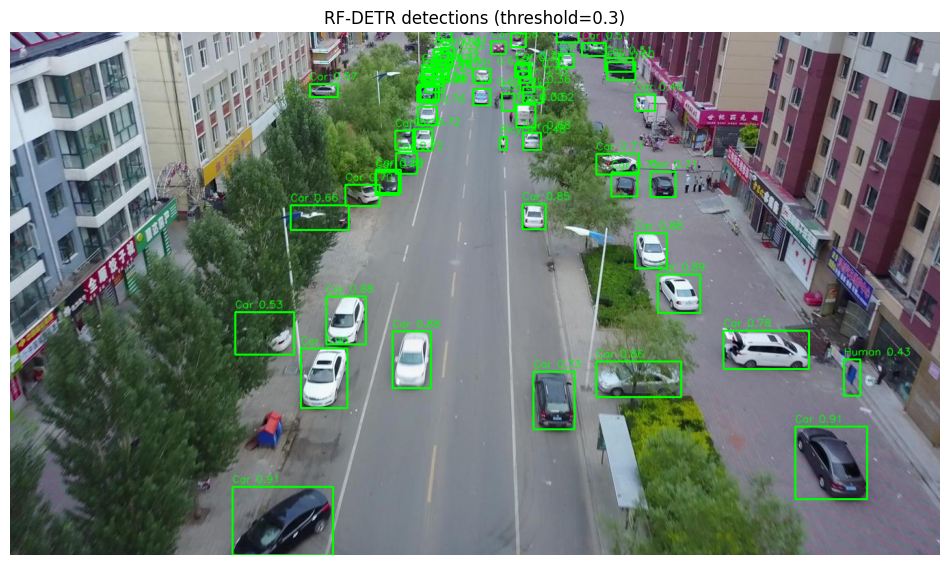

In [2]:
# ============================================================
# Cell 2: Load trained RF-DETR + visualize detections
# ============================================================

from pathlib import Path
import random
import torch
import cv2
import matplotlib.pyplot as plt

# -----------------------------
# 1) Paths + config
# -----------------------------
PHASE_ROOT = Path.cwd().parent.parent
RFDETR_MODELS_DIR = PHASE_ROOT / "rfdetr" / "models"
ENHANCED_RFDETR_MODELS_DIR = RFDETR_MODELS_DIR / "enhanced-training"

CKPT_PATH = ENHANCED_RFDETR_MODELS_DIR / "visdrone_rfdetr_nano_best_ema.pth"
VAL_IMG_DIR = PHASE_ROOT / "visdrone-dataset-rgb" / "val" / "images"

THRESHOLD = 0.30

# Phase class names
PHASE_CLASSES = {
    1: "Human",
    2: "Bicycle",
    3: "Car",
    4: "Truck",
    5: "Bus",
    6: "Other",
}

assert CKPT_PATH.exists(), f"Checkpoint not found: {CKPT_PATH}"
assert VAL_IMG_DIR.exists(), f"Val image dir not found: {VAL_IMG_DIR}"

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)
print("Checkpoint:", CKPT_PATH)

# -----------------------------
# 2) Load model (RF-DETR supported path)
# -----------------------------
global DETECTOR, _DETECTOR_CKPT
if "DETECTOR" not in globals() or "_DETECTOR_CKPT" not in globals() or _DETECTOR_CKPT != str(CKPT_PATH):
    print("Loading detector from checkpoint...")
    DETECTOR = RFDETRNano(pretrain_weights=str(CKPT_PATH))
    _DETECTOR_CKPT = str(CKPT_PATH)

DETECTOR.model.model.to(device)
DETECTOR.model.model.eval()
print("Detector loaded and ready.")

# -----------------------------
# 3) Pick a random image and run prediction
# -----------------------------
imgs = list(VAL_IMG_DIR.glob("*.jpg"))
assert imgs, f"No images found in: {VAL_IMG_DIR}"

image_path = str(random.choice(imgs))
print("Sanity test image:", image_path)

det = DETECTOR.predict(image_path, threshold=THRESHOLD)
print(f"Detections: {len(det.xyxy)} (threshold={THRESHOLD})")

# -----------------------------
# 4) Visualize boxes
# -----------------------------
img_bgr = cv2.imread(image_path)
if img_bgr is None:
    raise FileNotFoundError(f"Could not read image: {image_path}")

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

for box, score, cls in zip(det.xyxy, det.confidence, det.class_id):
    x1, y1, x2, y2 = map(int, box.tolist())
    cls = int(cls)
    label = PHASE_CLASSES.get(cls, f"class_{cls}")
    text = f"{label} {float(score):.2f}"

    cv2.rectangle(img_rgb, (x1, y1), (x2, y2), (0, 255, 0), 2)
    cv2.putText(
        img_rgb,
        text,
        (x1, max(0, y1 - 6)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        (0, 255, 0),
        1,
        cv2.LINE_AA,
    )

plt.figure(figsize=(12, 8))
plt.imshow(img_rgb)
plt.axis("off")
plt.title(f"RF-DETR detections (threshold={THRESHOLD})")
plt.show()

In [3]:
# ============================================================
# Cell 3: Initialize ByteTrack
# ============================================================

import inspect
import numpy as np
import cv2

assert SUPERVISION_OK, "supervision is not installed/importable. Install with: pip install supervision"

# ---- Desired tracking settings (we'll tune later) ----
TRACK_THRESH = 0.30
TRACK_BUFFER = 30
MATCH_THRESH = 0.80
FRAME_RATE   = 30

# ---- Build kwargs based on what this supervision version supports ----
sig = inspect.signature(sv.ByteTrack.__init__)
params = set(sig.parameters.keys())

kwargs = {}

# Newer supervision naming
if "track_activation_threshold" in params:
    kwargs["track_activation_threshold"] = TRACK_THRESH
if "lost_track_buffer" in params:
    kwargs["lost_track_buffer"] = TRACK_BUFFER
if "minimum_matching_threshold" in params:
    kwargs["minimum_matching_threshold"] = MATCH_THRESH
if "frame_rate" in params:
    kwargs["frame_rate"] = FRAME_RATE

# Older naming (what we tried originally)
if "track_thresh" in params:
    kwargs["track_thresh"] = TRACK_THRESH
if "track_buffer" in params:
    kwargs["track_buffer"] = TRACK_BUFFER
if "match_thresh" in params:
    kwargs["match_thresh"] = MATCH_THRESH

# Fallback: if none of these are accepted, instantiate without args
try:
    TRACKER = sv.ByteTrack(**kwargs)
except TypeError:
    TRACKER = sv.ByteTrack()

print("ByteTrack initialized")
print("ByteTrack init kwargs used:", kwargs)

# -----------------------------
# Helper: RF-DETR detections -> supervision.Detections
# -----------------------------
def rfdetr_to_sv_detections(det, min_conf=0.30):
    xyxy = np.asarray(det.xyxy, dtype=np.float32)
    conf = np.asarray(det.confidence, dtype=np.float32)
    cls  = np.asarray(det.class_id, dtype=np.int32)

    keep = conf >= float(min_conf)
    return sv.Detections(
        xyxy=xyxy[keep],
        confidence=conf[keep],
        class_id=cls[keep]
    )

# -----------------------------
# Helper: Draw tracks
# -----------------------------
def draw_tracks(frame_bgr, detections: "sv.Detections", class_map: dict, show_conf=True):
    out = frame_bgr.copy()
    tracker_ids = getattr(detections, "tracker_id", None)

    for i, box in enumerate(detections.xyxy):
        x1, y1, x2, y2 = box.astype(int).tolist()
        cls = int(detections.class_id[i]) if detections.class_id is not None else -1
        conf = float(detections.confidence[i]) if detections.confidence is not None else 0.0

        tid = int(tracker_ids[i]) if tracker_ids is not None and tracker_ids[i] is not None else -1
        label = class_map.get(cls, f"class_{cls}")

        text = f"ID {tid}: {label}" if tid >= 0 else label
        if show_conf:
            text += f" {conf:.2f}"

        cv2.rectangle(out, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(out, text, (x1, max(0, y1 - 6)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1, cv2.LINE_AA)

    return out

print("Helpers ready: rfdetr_to_sv_detections(), draw_tracks()")

ByteTrack initialized
ByteTrack init kwargs used: {'track_activation_threshold': 0.3, 'lost_track_buffer': 30, 'minimum_matching_threshold': 0.8, 'frame_rate': 30}
Helpers ready: rfdetr_to_sv_detections(), draw_tracks()


In [4]:
# ============================================================
# Cell 4: Frames folder OR video file -> Detect (every N) -> ByteTrack -> Output mp4
# ============================================================

from pathlib import Path
import cv2
import numpy as np
from tqdm.auto import tqdm

# -----------------------------
# 1) Input configuration
# -----------------------------
# FRAMES_DIR = Path(PHASE_ROOT) / "rfdetr" / "videos" / "uav0000120_04775_v"
VIDEO_PATH = Path(PHASE_ROOT) / "rfdetr" / "videos" / "custom_video.mp4"

# OUTPUT_PATH = Path(PHASE_ROOT) / "rfdetr" / "videos" / "tracked_output_uav0000120_04775_v.mp4"
OUTPUT_PATH = Path(PHASE_ROOT) / "rfdetr" / "videos" / "tracked_output_custom_video.mp4"

DETECT_EVERY_N = 1
DET_THRESHOLD  = 0.30
MIN_BOX_AREA   = 30 * 30

FPS = 30.0
CLASS_MAP = PHASE_CLASSES

assert (VIDEO_PATH is not None) or FRAMES_DIR.exists(), "Provide VIDEO_PATH or a valid FRAMES_DIR."

# -----------------------------
# 2) Build frame iterator
# -----------------------------
def list_frames(folder: Path):
    exts = (".jpg", ".jpeg", ".png")
    frames = [p for p in folder.iterdir() if p.suffix.lower() in exts]
    return sorted(frames, key=lambda p: p.name)

frames_list = None
cap = None

if VIDEO_PATH is not None:
    cap = cv2.VideoCapture(str(VIDEO_PATH))
    assert cap.isOpened(), f"Could not open video: {VIDEO_PATH}"
    fps = cap.get(cv2.CAP_PROP_FPS)
    if fps is None or fps <= 1:
        fps = FPS
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
else:
    frames_list = list_frames(FRAMES_DIR)
    assert len(frames_list) > 0, f"No frames found in: {FRAMES_DIR}"
    first = cv2.imread(str(frames_list[0]))
    assert first is not None, f"Could not read first frame: {frames_list[0]}"
    height, width = first.shape[:2]
    fps = FPS
    total_frames = len(frames_list)

print("Input:", VIDEO_PATH if VIDEO_PATH is not None else str(FRAMES_DIR))
print(f"Frames: {total_frames} | Size: {width}x{height} | Output FPS: {fps}")
print(f"Detect every N: {DETECT_EVERY_N}")

# -----------------------------
# 3) Configure tracker and reset for a new sequence
# -----------------------------
try:
    if hasattr(TRACKER, "frame_rate"):
        TRACKER.frame_rate = int(round(fps))
except Exception:
    pass

# Reset tracker so old tracks don’t leak between runs (if supported)
if hasattr(TRACKER, "reset"):
    TRACKER.reset()

# Track metadata: track_id -> (class_id, confidence)
track_meta = {}

def build_tensors_from_detections(detections: "sv.Detections") -> np.ndarray:
    """
    ByteTrack tensor format: Nx5 [x1, y1, x2, y2, score]
    """
    if len(detections) == 0:
        return np.zeros((0, 5), dtype=np.float32)
    return np.hstack([
        detections.xyxy.astype(np.float32),
        detections.confidence.reshape(-1, 1).astype(np.float32),
    ])

def active_tracks_to_boxes_and_ids(tracker) -> tuple[list[np.ndarray], list[int]]:
    """
    Convert tracker.tracked_tracks to (boxes, ids).
    Each track has tlbr (x1,y1,x2,y2) and external_track_id.
    """
    tracks = getattr(tracker, "tracked_tracks", [])
    boxes, ids = [], []
    for t in tracks:
        boxes.append(np.array(t.tlbr, dtype=np.float32))
        ids.append(int(t.external_track_id))
    return boxes, ids

# -----------------------------
# 4) Video writer
# -----------------------------
OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
fourcc = cv2.VideoWriter_fourcc(*"mp4v")
writer = cv2.VideoWriter(str(OUTPUT_PATH), fourcc, fps, (width, height))
assert writer.isOpened(), f"Could not open writer: {OUTPUT_PATH}"

# -----------------------------
# 5) Main loop
# -----------------------------
pbar = tqdm(total=total_frames, desc="Processing frames")

for frame_idx in range(total_frames):
    # Load frame
    if cap is not None:
        ok, frame_bgr = cap.read()
        if not ok:
            break
    else:
        frame_bgr = cv2.imread(str(frames_list[frame_idx]))
        if frame_bgr is None:
            continue

    # Detection frame?
    if frame_idx % DETECT_EVERY_N == 0:
        temp_path = "temp_frame.jpg"
        cv2.imwrite(temp_path, frame_bgr)

        det = DETECTOR.predict(temp_path, threshold=DET_THRESHOLD)
        detections = rfdetr_to_sv_detections(det, min_conf=DET_THRESHOLD)

        # Filter tiny boxes
        if len(detections) > 0:
            xyxy = detections.xyxy
            areas = (xyxy[:, 2] - xyxy[:, 0]) * (xyxy[:, 3] - xyxy[:, 1])
            keep = areas >= MIN_BOX_AREA
            detections = detections[keep]

        # Advance tracker using tensors (core tracking update)
        tensors = build_tensors_from_detections(detections)
        _ = TRACKER.update_with_tensors(tensors)

        # ALSO run update_with_detections on detection frames to get tracker_id mapping
        det_with_ids = TRACKER.update_with_detections(detections)
        if len(det_with_ids) > 0 and getattr(det_with_ids, "tracker_id", None) is not None:
            for i in range(len(det_with_ids)):
                tid = int(det_with_ids.tracker_id[i])
                cls = int(det_with_ids.class_id[i])
                conf = float(det_with_ids.confidence[i])
                track_meta[tid] = (cls, conf)

    else:
        # No detections: predict/propagate tracks forward
        _ = TRACKER.update_with_tensors(np.zeros((0, 5), dtype=np.float32))

    # Draw ACTIVE TRACKS every frame (so boxes persist)
    out = frame_bgr.copy()
    boxes, ids = active_tracks_to_boxes_and_ids(TRACKER)

    for box, tid in zip(boxes, ids):
        x1, y1, x2, y2 = box.astype(int).tolist()
        cls, conf = track_meta.get(tid, (-1, 0.0))
        label = CLASS_MAP.get(cls, f"class_{cls}") if cls != -1 else "unknown"
        text = f"ID {tid}: {label} {conf:.2f}"

        cv2.rectangle(out, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(out, text, (x1, max(0, y1 - 6)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1, cv2.LINE_AA)

    writer.write(out)
    pbar.update(1)

pbar.close()
if cap is not None:
    cap.release()
writer.release()

print(f"\nDone. Saved tracked video to: {OUTPUT_PATH}")

Input: C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\rfdetr\videos\custom_video.mp4
Frames: 956 | Size: 768x432 | Output FPS: 25.0
Detect every N: 1


Processing frames:   0%|          | 0/956 [00:00<?, ?it/s]


Done. Saved tracked video to: C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\rfdetr\videos\tracked_output_custom_video.mp4
